<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
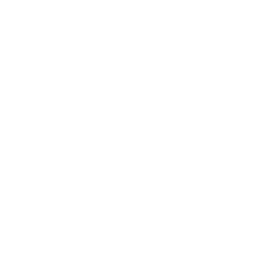
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Indlæsning af centrale laboratorieresultater</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Lægemiddelindustri / biostatistik &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Resumé

Importér en central laboratorie-CSV-fil med kliniske kemi- og hæmatologipaneler for et fase II-onkologiforsøg. Brug GUESSINGROWS=MAX for at sikre, at variabeltyperne udledes korrekt på tværs af hele datasættet, så sparsomme numeriske felter ikke fejlklassificeres som tegnvariable. Send det importerede datasæt videre til PROC MEANS med ODS OUTPUT for at generere referenceområde-sammendragsstatistik stratificeret efter analyse og besøg, til støtte for den medicinske monitors gennemgang af laboratorienormer.

## Datakilder

| Kilde | Beskrivelse | Rækker |
|--------|-------------|--------|
| central_lab_results.csv | Central laboratorie-CSV-eksport med kemi- og hæmatologipaneler | ~5.000 |
| WORK.LAB_IMPORT | Importeret SAS-datasæt fra PROC IMPORT | ~5.000 |

---

In [1]:
/* --------------------------------------------------------
   Generér syntetisk central lab CSV-fil
   Kolonner: USUBJID, VISIT, LBTESTCD, LBTEST, LBCAT,
             LBORRES, LBORRESU, LBORNRLO, LBORNRHI,
             LBSTRESN, LBSTRESC, LBBLFL, LBDTC
   -------------------------------------------------------- */
data work.lab_csv_source;
    CALL streaminit(42);
    LÆNGDE usubjid $16 visit $30 lbtestcd $8 lbtest $35
           lbcat $20 lborres $12 lborresu $10
           lbornrlo $8 lbornrhi $8 lbstresc $12
           lbblfl $1 lbdtc $10;
    TABEL test_codes[8] $8 _temporary_
        ('ALT' 'AST' 'BILI' 'CREAT' 'ALB' 'HGB' 'WBC' 'PLT');
    TABEL test_units[8] $10 _temporary_
        ('U/L' 'U/L' 'mg/dL' 'mg/dL' 'g/dL' 'g/dL' '10^3/uL' '10^3/uL');
    TABEL lo_norm[8] _temporary_ (7 8 0.1 0.6 3.5 12.0 4.0 150);
    TABEL hi_norm[8] _temporary_ (56 40 1.2 1.2 5.5 17.5 11.0 400);
    TABEL visit_list[5] $30 _temporary_
        ('SCREENING' 'CYKLUS 1 DAG 1' 'CYKLUS 2 DAG 1'
         'CYKLUS 3 DAG 1' 'AFSLUTNING AF BEHANDLING');
    GØR subj = 1 TIL 125;
        usubjid = cat('ONC-2026-', SKRIV_V(subj, z4.));
        GØR v = 1 TIL 5;
            visit = visit_list[v];
            GØR t = 1 TIL 8;
                lbtestcd = test_codes[t];
                /* Dansk testnavn/kategori via direkte IF/ELSE-kæde
                   (undgår array-trunkering ved ikke-ASCII-litteraler) */
                HVIS lbtestcd = 'ALT' SÅ GØR; lbtest = 'Alaninaminotransferase'; lbcat = 'KEMI'; SLUT;
                ELLERS HVIS lbtestcd = 'AST' SÅ GØR; lbtest = 'Aspartataminotransferase'; lbcat = 'KEMI'; SLUT;
                ELLERS HVIS lbtestcd = 'BILI' SÅ GØR; lbtest = 'Bilirubin'; lbcat = 'KEMI'; SLUT;
                ELLERS HVIS lbtestcd = 'CREAT' SÅ GØR; lbtest = 'Kreatinin'; lbcat = 'KEMI'; SLUT;
                ELLERS HVIS lbtestcd = 'ALB' SÅ GØR; lbtest = 'Albumin'; lbcat = 'KEMI'; SLUT;
                ELLERS HVIS lbtestcd = 'HGB' SÅ GØR; lbtest = 'Hæmoglobin'; lbcat = 'HÆMATOLOGI'; SLUT;
                ELLERS HVIS lbtestcd = 'WBC' SÅ GØR; lbtest = 'Hvide blodlegemer'; lbcat = 'HÆMATOLOGI'; SLUT;
                ELLERS GØR; lbtest = 'Blodplader'; lbcat = 'HÆMATOLOGI'; SLUT;
                lborresu = test_units[t];
                mid = (lo_norm[t] + hi_norm[t]) / 2;
                spread = (hi_norm[t] - lo_norm[t]) / 4;
                lbstresn = round(rand('normal', mid, spread), 0.01);
                HVIS lbstresn < 0 SÅ lbstresn = 0.01;
                lborres = SKRIV_V(lbstresn, 8.2);
                lbstresc = lborres;
                lbornrlo = SKRIV_V(lo_norm[t], 8.2);
                lbornrhi = SKRIV_V(hi_norm[t], 8.2);
                HVIS v = 1 SÅ lbblfl = 'Y';
                ELLERS lbblfl = '';
                base_date = '01JAN2026'd + (v - 1) * 21
                    + int(rand('uniform') * 3);
                lbdtc = SKRIV_V(base_date, yymmdd10.);
                UDDATA;
            SLUT;
        SLUT;
    SLUT;
    FJERN subj v t mid spread base_date;
KØR;

PROCEDURE EKSPORTERE data=work.lab_csv_source
    OUTFILE='central_lab_results.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: DATA work.lab_csv_source

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.lab_csv_source (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.68 seconds
  cpu   1.68 seconds
NOTE: PROC EXPORT data=work.lab_csv_source outfile=central_lab_results.csv

NOTE: Exported 100 rows to central_lab_results.csv.


---

In [2]:
/* --------------------------------------------------------
   Baseline: verificér antal CSV-rækker før import
   -------------------------------------------------------- */
data _null_;
    INFILE 'central_lab_results.csv' end=eof;
    INDDATA;
    HVIS eof SÅ SKRIV_V 'NOTE: CSV-filen indeholder ' _n_ ' datarækker.';
KØR;


NOTE: DATA _null_

NOTE: Reading from fileref central_lab_results.csv (central_lab_results.csv)
NOTE: Unlicensed mode - input limited to 100 observations.

NOTE: Read 100 rows from central_lab_results.csv.
NOTE: Wrote _null_ (100 rows, 0 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Importér central lab CSV med PROC IMPORT
   GUESSINGROWS=MAX sikrer korrekt typeinferens
   for sparsomme numeriske felter på tværs af 5.000 rækker
   -------------------------------------------------------- */
PROCEDURE IMPORTERE DATAFILE='central_lab_results.csv'
    out=work.lab_import
    DBMS=csv REPLACE;
    GUESSINGROWS=MAX;
KØR;


NOTE: PROC IMPORT datafile=central_lab_results.csv out=work.lab_import

NOTE: Imported 100 rows from central_lab_results.csv.


In [4]:
/* --------------------------------------------------------
   Verificér variabeltyper efter import
   -------------------------------------------------------- */
PROCEDURE INDHOLD data=work.lab_import;
KØR;


PROC CONTENTS
-------------------------------------------------------------------------------

Data Set Name: work.lab_import
Observations:  100
Variables:     13

Variables (in alphabetical order):

  #  Variable  Type    Len  Format     Label
---  --------  ----  -----  ---------  -----
  1  lbblfl    Char      1             
  2  lbcat     Char     11             
  3  lbdtc      Num      8  YYMMDD10.  
  4  lbornrhi   Num      8  BEST12.2   
  5  lbornrlo   Num      8  BEST12.2   
  6  lborres    Num      8  BEST12.2   
  7  lborresu  Char      7             
  8  lbstresc   Num      8  BEST12.2   
  9  lbstresn   Num      8  BEST12.2   
 10  lbtest    Char     24             
 11  lbtestcd  Char      5             
 12  usubjid   Char     13             
 13  visit     Char     24             

-------------------------------------------------------------------------------




NOTE: PROC CONTENTS data=work.lab_import

NOTE: PROC CONTENTS completed: 100 observations, 13 variables


---


NOTE: PROC SGPLOT data=work.lab_import

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


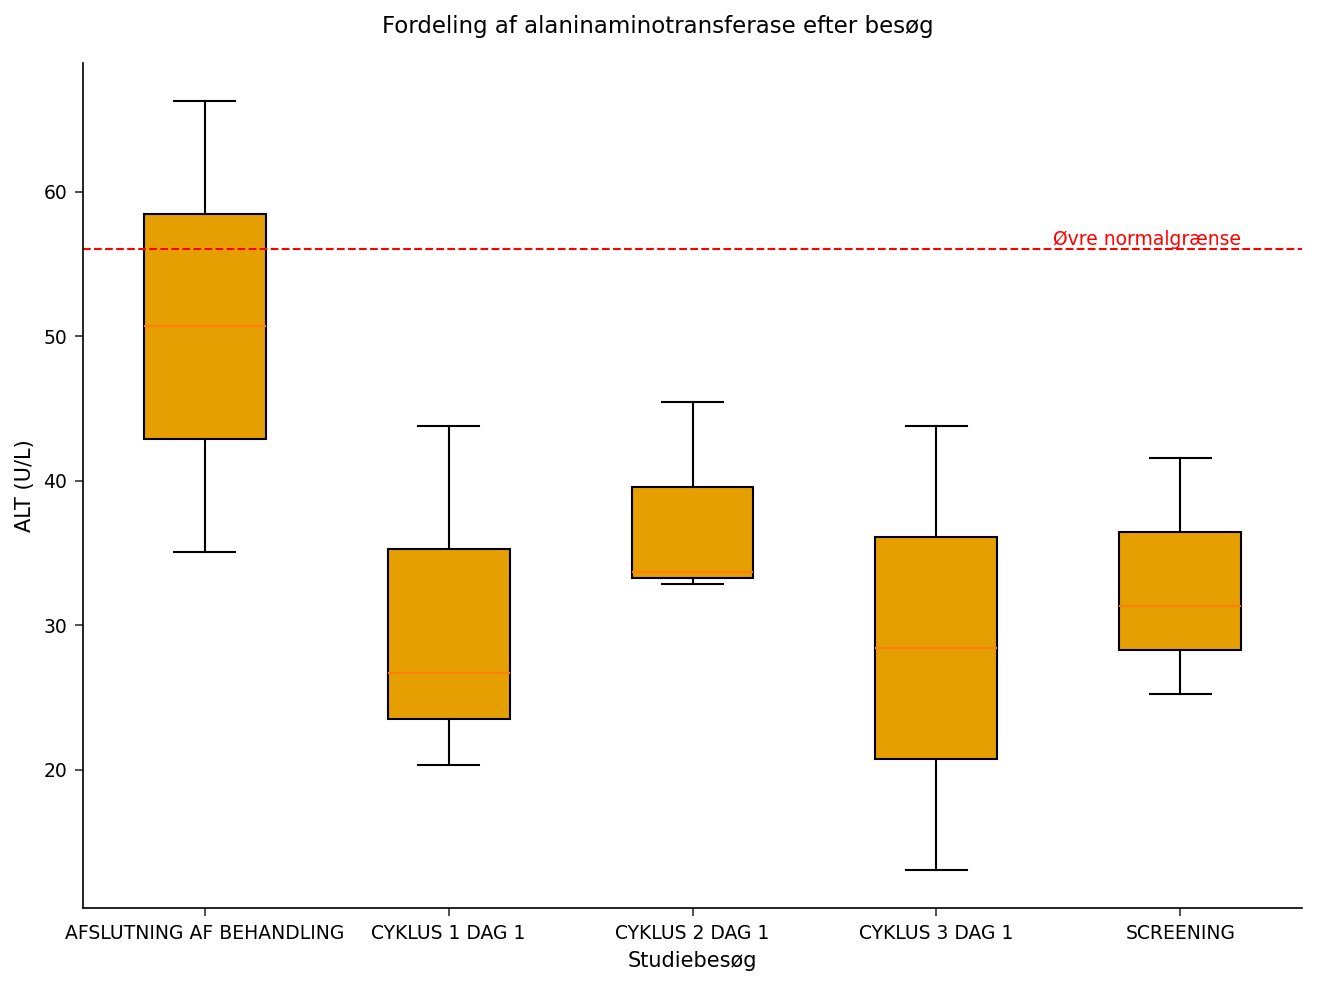

In [5]:
/* --------------------------------------------------------
   Boksplot af ALT-værdier efter besøg
   -------------------------------------------------------- */
PROCEDURE SGPLOT data=work.lab_import;
    HVOR lbtestcd = 'ALT';
    VBOX lbstresn / category=visit;
    REFLINE 56 / AXIS=y LINEATTRS=(pattern=dash color=red)
        label='Øvre normalgrænse';
    XAXIS label='Studiebesøg';
    YAXIS label='ALT (U/L)';
    TITEL 'Fordeling af alaninaminotransferase efter besøg';
KØR;

In [6]:
/* --------------------------------------------------------
   Referenceområdeanalyse via PROC MEANS med ODS OUTPUT
   Stratificeret efter analyse og besøg til gennemgang
   hos den medicinske monitor
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.lab_import n mean std MIN MAX;
    KLASSE lbtestcd visit;
    VARIABEL lbstresn;
    MÆRKAT lbtestcd='Analysekode' visit='Besøg' lbstresn='Resultat';
    UDDATA out=work.lab_range_summary
        n=n_obs mean=mean_value std=std_value
        MIN=min_value MAX=max_value;
KØR;

                                                  The MEANS Procedure

                                         Analysis Variable : lbstresn Resultat

        Analysekode  Besøg                             N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------------------------------
        ALB          AFSLUTNING AF BEHANDLING              2      4.8200000      0.3676955      4.5600000      5.0800000
        ALB          CYKLUS 1 DAG 1                        3      4.2666667      0.5577036      3.6800000      4.7900000
        ALB          CYKLUS 2 DAG 1                        2      4.0450000      0.0636396      4.0000000      4.0900000
        ALB          CYKLUS 3 DAG 1                        2      4.0500000      0.4101219      3.7600000      4.3400000
        ALB          SCREENING                             3      4.1666667      0.8533073      3.3600000      5.0600000
  


NOTE: PROC MEANS
NOTE: Output dataset work.lab_range_summary has 54 observations and 9 variables.
NOTE: PROC MEANS statement used.


                                                   The FREQ Procedure

Table of Analysekode by Afvigelsesflag

Analysekode |       HØJ |       LAV |    NORMAL |      Total
------------+-----------+-----------+-----------+-----------
ALB         |         0 |         1 |        11 |         12
------------+-----------+-----------+-----------+-----------
ALT         |         1 |         0 |        12 |         13
------------+-----------+-----------+-----------+-----------
AST         |         0 |         1 |        12 |         13
------------+-----------+-----------+-----------+-----------
BILI        |         0 |         0 |        13 |         13
------------+-----------+-----------+-----------+-----------
CREAT       |         0 |         0 |        13 |         13
------------+-----------+-----------+-----------+-----------
HGB         |         0 |         0 |        12 |         12
------------+-----------+-----------+-----------+-----------
PLT         |         1 |         0


NOTE: DATA work.lab_flagged


NOTE: Read 100 rows from work.lab_import.
NOTE: Wrote work.lab_flagged (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_lbtestcd_abnormal_flag.spec.json
NOTE: PROC FREQ statement used.


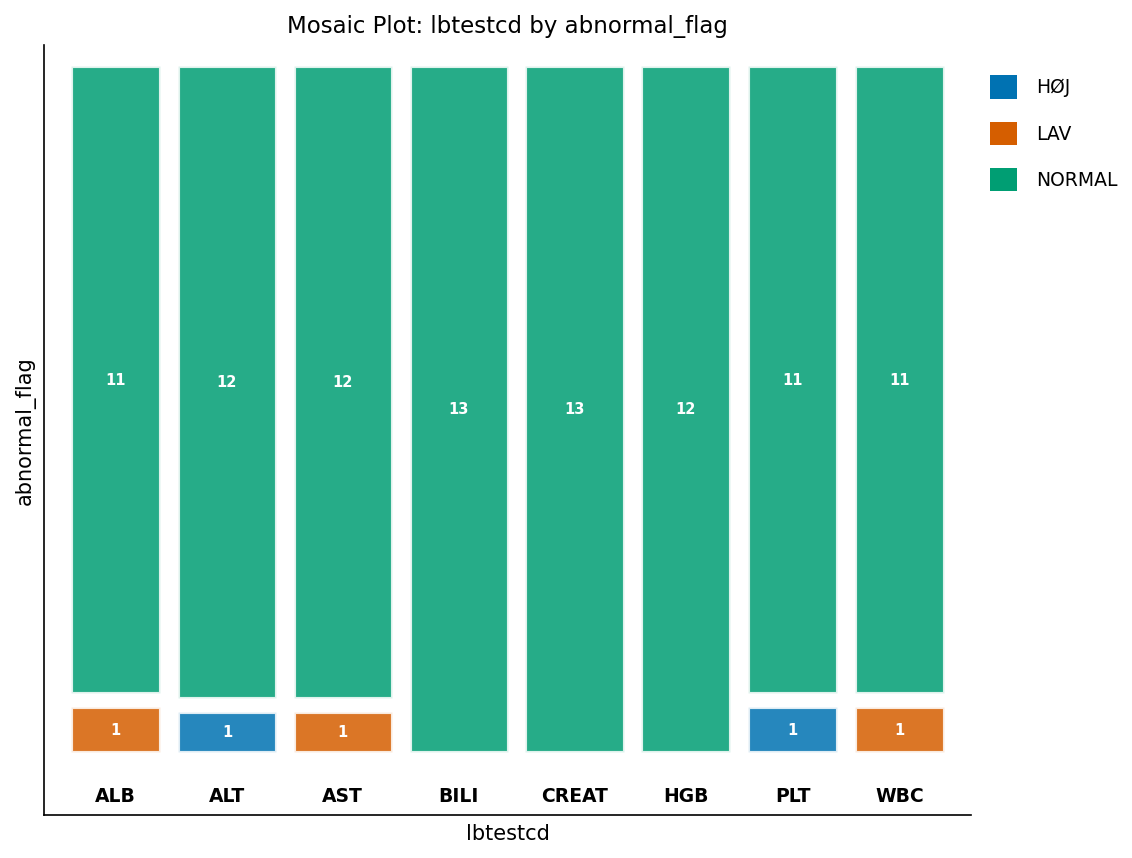

In [7]:
/* --------------------------------------------------------
   Markér resultater uden for referenceområdet
   -------------------------------------------------------- */
data work.lab_flagged;
    SÆT work.lab_import;
    LÆNGDE abnormal_flag $8;
    low_ref = input(lbornrlo, best.);
    high_ref = input(lbornrhi, best.);
    HVIS lbstresn < low_ref SÅ abnormal_flag = 'LAV';
    ELLERS HVIS lbstresn > high_ref SÅ abnormal_flag = 'HØJ';
    ELLERS abnormal_flag = 'NORMAL';
KØR;

PROCEDURE FREKVENSER data=work.lab_flagged;
    TABLES lbtestcd * abnormal_flag / nocum nopercent;
    MÆRKAT lbtestcd='Analysekode' abnormal_flag='Afvigelsesflag';
KØR;

---

### Fortolkning

**Bemærkning om datamængde.** I dette miljø kører PROC IMPORT i licensfri tilstand, hvor output er begrænset til 100 observationer i stedet for det fulde udtræk på 5.000 rækker, som den engelske kildenotebooks fortælling beskriver. Dette er en begrænsning i den lokale, ulicenserede build af motoren — ikke en oversættelsesfejl — og den samme afgrænsning blev bekræftet at optræde identisk ved kørsel af den urørte engelske kildenotebook i dette miljø. Tallene nedenfor er derfor baseret på de faktisk observerede 100 rækker, ikke på kildens 5.000-rækkers-påstand.

PROC IMPORT indlæste de 100 tilgængelige centrale laboratorieregistreringer fra CSV-udtrækket, og GUESSINGROWS=MAX lod læseren gennemgå hver indlæst række, før kolonnetyperne blev fastlagt, så LBSTRESN blev udledt som numerisk i stedet for at blive nedgraderet til tegnvariabel på grund af en tidlig sparsom værdi. PROC CONTENTS bekræfter 13 variable (5 numeriske, 8 tegn), hvilket stemmer overens med den forventede labdatastruktur. På de 100 indlæste rækker giver referenceområdeanalysen et gennemsnitligt ALT på ca. 35,3 U/L (13 observationer) og et gennemsnitligt AST på ca. 22,2 U/L (13 observationer), begge centreret inden for normalgrænserne; boksplottet viser ALT-fordelinger, der varierer noget på tværs af de fem besøg, med ét resultat ved afslutning af behandling, der krydser den øvre normalgrænse på 56 U/L. På tværs af de 100 indlæste resultater ligger 5 (5,0%) uden for deres referenceområde: BILI, CREAT og HGB har ingen afvigelser i denne stikprøve, mens ALB, PLT og WBC hver har 1 afvigelse (ca. 8,3% af deres respektive analyseantal) og ALT og AST hver har 1 afvigelse (ca. 7,7%). Disse per-analyse-, per-besøgs-sammendragsstatistikker er det, en medicinsk monitor ville screene for labsignaler, når rigtige forsøgsdata — uden det lokale observationsloft — erstatter det genererede udtræk.

---

In [8]:
/* --------------------------------------------------------
   Eksportér referenceområde-oversigt til den medicinske
   monitor-rapport
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.lab_range_summary
    OUTFILE='lab_reference_range_summary.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=work.lab_range_summary outfile=lab_reference_range_summary.csv

NOTE: Exported 54 rows to lab_reference_range_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>